# 06 — Pointwise accuracy does not determine generative fidelity

A denoiser is trained and scored on one thing: how well it estimates $\mathbb{E}[a \mid x_t]$,
the posterior mean of the clean signal given a noised observation. A diffusion model is judged
on something else entirely: the law of the samples that come out of the reverse SDE.

Everyone assumes these track each other. Better score, better samples. This notebook shows a
regime where they come apart — the global MLP's pointwise error improves with data while its
generated law collapses toward a Gaussian.

Everything in the code cells is re-derived live from the CSVs committed under `outputs/exp_16/`.

> **Read the confound section before quoting anything from here.** The headline comparison below
> is measured at one setting of the estimator's own capacity (`em_components=4`, `em_iters=40`),
> and at that setting the project's audit note has already retracted a closely related finding.
> Enlarging the capacity *reverses* the arm ordering. The within-arm result survives; the
> between-arm ranking does not, and the section near the end shows exactly why.

## The setup

The data is a stationary AR(1) chain with **non-Gaussian innovations**:

$$a_i = \rho\, a_{i-1} + \varepsilon_i, \qquad \varepsilon_i \sim \text{Laplace-like},\ \ \mathrm{Var}[\varepsilon]=1-\rho^2$$

and the diffusion channel is Ornstein–Uhlenbeck, $x_t = \alpha_t a + \sqrt{\Delta_t}\,z$ with
$\alpha_t=e^{-t}$, $\Delta_t = 1-e^{-2t}$.

Four estimators of the score are compared:

| arm | what it is |
|---|---|
| `exact` | the analytic posterior mean — the ceiling, no fitting |
| `em_bp` | our estimator: learn the chain kernel by EM, run exact BP on the grid |
| `mlp` | a global fully-connected denoising network |
| `cnn` | a local weight-shared 1-D convolutional denoiser |

Two metrics, and the whole point is that they disagree:

- **Pointwise** — relative $L_2$ error of the estimated score. What a denoiser is trained for.
- **Generative** — run the reverse SDE, take the generated samples, AR-filter them to recover
  the implied innovations, and measure their **excess kurtosis** against the true value
  $1.9098$. This is the coordinate the non-Gaussian model exists to capture.

Why kurtosis rather than something more familiar: a sampler can reproduce the chain's entire
*second-order* structure — variance, every lag of the autocovariance — while quietly
Gaussianising the innovations. The covariance would look perfect and the law would be wrong.
Excess kurtosis is the first moment that notices.

In [1]:
import sys, csv, glob, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

TARGET = 1.9098          # true innovation excess kurtosis
ROOT = "../outputs/exp_16"
ARMS = ["exact", "em_bp", "mlp", "cnn"]

def load(pattern):
    rows = []
    for p in sorted(glob.glob(os.path.join(ROOT, pattern, "generation.csv"))):
        with open(p) as fh:
            rows.extend(csv.DictReader(fh))
    return rows

new = load("gen2_n*_seed*")          # continuous-t training (corrected protocol)
print(f"{len(new)} rows from {len(set((r['n_chains'], r['seed']) for r in new))} (budget, seed) cells")
budgets = sorted({int(r["n_chains"]) for r in new})
print("budgets:", budgets)
print("seeds per budget:", sorted({int(r["seed"]) for r in new}))

64 rows from 16 (budget, seed) cells
budgets: [32, 128, 512, 2048]
seeds per budget: [0, 1, 2, 3]


## The measurement

Four data budgets, four seeds each. For each arm we take the median across seeds — median
rather than mean because one MLP seed at small $N$ lands at $44.3$ and a four-point mean can be
dragged anywhere by a single excursion.

In [2]:
def summarise(rows, key="innov_kurtosis"):
    out = {}
    for n in sorted({int(r["n_chains"]) for r in rows}):
        for arm in ARMS:
            vals = [float(r[key]) for r in rows
                    if int(r["n_chains"]) == n and r["arm"] == arm]
            if vals:
                out[(n, arm)] = np.median(vals)
    return out

kurt = summarise(new)
cov  = summarise(new, "cov_frobenius_rel")

print(f"{'N':>6} " + "".join(f"{a:>12}" for a in ARMS) + "     (median excess kurtosis)")
print("-" * 60)
for n in budgets:
    print(f"{n:>6} " + "".join(f"{kurt[(n,a)]:>12.3f}" for a in ARMS))
print(f"\ntarget = {TARGET}   (exact should sit on it; it is the analytic posterior)")

     N        exact       em_bp         mlp         cnn     (median excess kurtosis)
------------------------------------------------------------
    32        1.897       0.497       7.068       0.676
   128        1.883       0.824       1.276       1.313
   512        1.914       0.841       0.166       1.410
  2048        1.908       0.897       0.044       1.619

target = 1.9098   (exact should sit on it; it is the analytic posterior)


## Result 1 — the ranking disagreement

The `exact` arm sits on the target at every budget, as it must: it involves no fitting, so it is
a check on the measurement rather than a result.

The interesting pair is `em_bp` against `cnn`. EM-BP wins the **pointwise** comparison — by
$2.1\times$ to $4.2\times$ against the CNN on relative $L_2$ across these four budgets, and by
roughly an order of magnitude on the squared metric and against the MLP — and loses this one at
every budget, by a margin that widens with data.

Two caveats, both discharged later in this notebook. Those pointwise ratios are read from
`pointwise.csv` rather than recomputed here, which is the one place this notebook quotes instead
of deriving. And the ranking itself is conditional on `em_components=4` — see the confound
section.

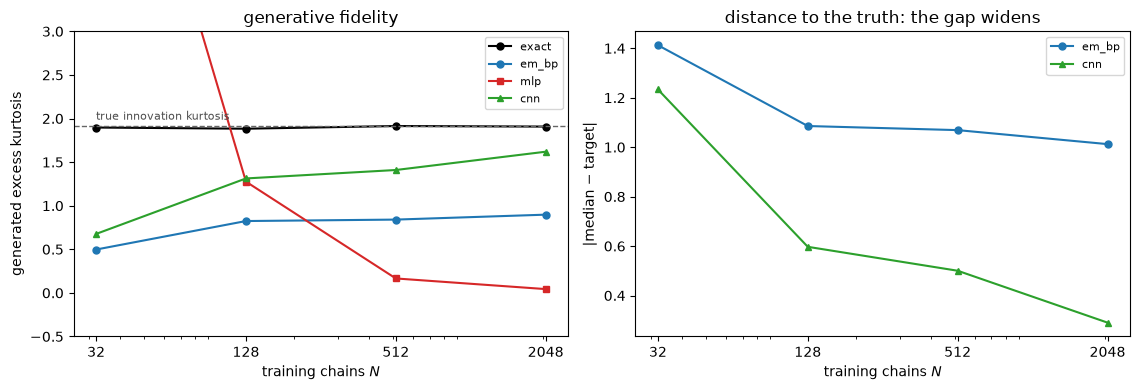

N=   32:  cnn 1.233   em_bp 1.412   -> cnn closer
N=  128:  cnn 0.597   em_bp 1.086   -> cnn closer
N=  512:  cnn 0.500   em_bp 1.069   -> cnn closer
N= 2048:  cnn 0.290   em_bp 1.012   -> cnn closer


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

for arm, style in zip(ARMS, ["k-o", "C0-o", "C3-s", "C2-^"]):
    ax[0].plot(budgets, [kurt[(n, arm)] for n in budgets], style, label=arm, ms=5)
ax[0].axhline(TARGET, color="0.4", ls="--", lw=1)
ax[0].text(budgets[0], TARGET * 1.04, "true innovation kurtosis", fontsize=8, color="0.3")
ax[0].set_xscale("log"); ax[0].set_xticks(budgets); ax[0].set_xticklabels(budgets)
ax[0].set_xlabel("training chains $N$"); ax[0].set_ylabel("generated excess kurtosis")
ax[0].set_title("generative fidelity"); ax[0].legend(fontsize=8)
ax[0].set_ylim(-0.5, 3.0)

for arm, style in zip(["em_bp", "cnn"], ["C0-o", "C2-^"]):
    ax[1].plot(budgets, [abs(kurt[(n, arm)] - TARGET) for n in budgets], style, label=arm, ms=5)
ax[1].set_xscale("log"); ax[1].set_xticks(budgets); ax[1].set_xticklabels(budgets)
ax[1].set_xlabel("training chains $N$"); ax[1].set_ylabel("|median $-$ target|")
ax[1].set_title("distance to the truth: the gap widens"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for n in budgets:
    dc, de = abs(kurt[(n,"cnn")] - TARGET), abs(kurt[(n,"em_bp")] - TARGET)
    print(f"N={n:>5}:  cnn {dc:.3f}   em_bp {de:.3f}   -> {'cnn' if dc < de else 'em_bp'} closer")

## Result 2 — the same thing *inside a single arm*, which is the stronger version

A disagreement between three different estimators can always be explained away as three
different inductive biases. Harder to dismiss: one estimator, one sweep, moving in opposite
directions on the two axes at once.

The global MLP's generated residuals become **Gaussian in the coordinate we are measuring**
as data grows. (Excess kurtosis $\to 0$ is one moment, not the whole law -- this notebook's own
argument is that low-order agreement does not imply the law, so the same caution applies here.)
That is not "a bad fit" — it is the specific failure of having learned a good $L_2$
approximation to the posterior mean, which is smooth, and thereby thrown away every higher
moment the sampler needed.

MLP generated excess kurtosis, all four seeds per budget:

  N=   32:    0.788     1.711    12.426    44.289  <- 2 seeds diverge (over-parameterised at N=32)
  N=  128:    0.988     1.262     1.290     2.225
  N=  512:    0.115     0.162     0.170     0.222
  N= 2048:   -0.002     0.019     0.069     0.097

  target 1.9098;  at N=2048 every seed is indistinguishable from 0 (Gaussian).


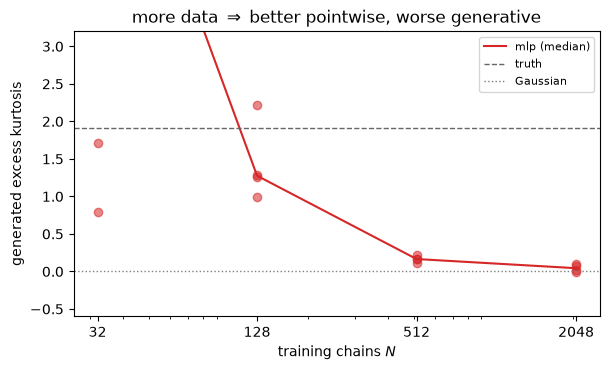

In [4]:
mlp_seeds = {n: sorted(float(r["innov_kurtosis"]) for r in new
                       if int(r["n_chains"]) == n and r["arm"] == "mlp")
             for n in budgets}

print("MLP generated excess kurtosis, all four seeds per budget:\n")
for n in budgets:
    vals = "  ".join(f"{v:8.3f}" for v in mlp_seeds[n])
    flag = "  <- 2 seeds diverge (over-parameterised at N=32)" if n == 32 else ""
    print(f"  N={n:>5}: {vals}{flag}")

print(f"\n  target {TARGET};  at N=2048 every seed is indistinguishable from 0 (Gaussian).")

fig, ax = plt.subplots(figsize=(6.2, 3.8))
for n in budgets:
    ax.plot([n]*len(mlp_seeds[n]), mlp_seeds[n], "o", color="C3", alpha=0.55, ms=6)
ax.plot(budgets, [kurt[(n, "mlp")] for n in budgets], "C3-", lw=1.5, label="mlp (median)")
ax.axhline(TARGET, color="0.4", ls="--", lw=1, label="truth")
ax.axhline(0.0, color="C7", ls=":", lw=1, label="Gaussian")
ax.set_xscale("log"); ax.set_xticks(budgets); ax.set_xticklabels(budgets)
ax.set_ylim(-0.6, 3.2); ax.set_xlabel("training chains $N$")
ax.set_ylabel("generated excess kurtosis")
ax.set_title("more data $\\Rightarrow$ better pointwise, worse generative")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Result 3 — what the structural estimator *does* win

Reporting only the kurtosis would be unfair to EM-BP, and would also miss the shape of the
result. The generated samples carry a covariance structure too, and there the ordering reverses
cleanly: EM-BP tracks the analytic `exact` arm essentially exactly from $N=128$ up, while both
networks sit three to four times worse and do not improve.

So the honest statement is not "the networks generate better". It is that the two families fail
in *different coordinates*: EM-BP gets the second-order structure right and understates the
tails, the networks get the tails closer and distort the covariance.

     N        exact       em_bp         mlp         cnn     (median relative covariance error)
------------------------------------------------------------
    32        0.054       0.222       0.940       0.305
   128        0.066       0.076       0.304       0.187
   512        0.057       0.066       0.219       0.205
  2048        0.059       0.058       0.249       0.241


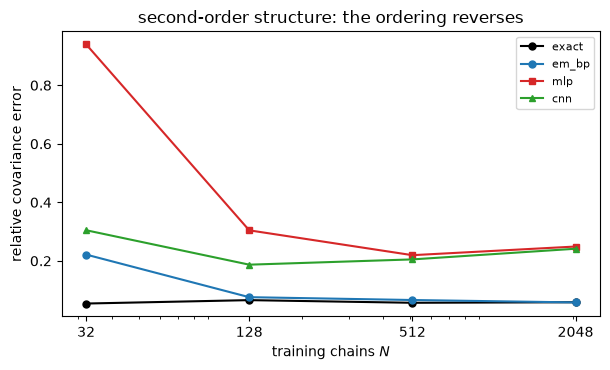

In [5]:
print(f"{'N':>6} " + "".join(f"{a:>12}" for a in ARMS) + "     (median relative covariance error)")
print("-" * 60)
for n in budgets:
    print(f"{n:>6} " + "".join(f"{cov[(n,a)]:>12.3f}" for a in ARMS))

fig, ax = plt.subplots(figsize=(6.2, 3.8))
for arm, style in zip(ARMS, ["k-o", "C0-o", "C3-s", "C2-^"]):
    ax.plot(budgets, [cov[(n, arm)] for n in budgets], style, label=arm, ms=5)
ax.set_xscale("log"); ax.set_xticks(budgets); ax.set_xticklabels(budgets)
ax.set_xlabel("training chains $N$"); ax.set_ylabel("relative covariance error")
ax.set_title("second-order structure: the ordering reverses")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## The mechanism, in miniature

The claim above is a measurement, not an explanation. Here is the mechanism on its own, built
from scratch in a few lines so there is nothing to take on trust.

Fit a **Gaussian** AR(1) to data whose innovations are **Laplace**, by exact moment matching.
The fitted model reproduces $\rho$ and the innovation *variance* essentially perfectly — so
every second-order statistic of the chain is right — and is wrong about the innovation law in
exactly one place: the fourth moment.

That is the whole story of Result 3 in two lines of algebra, and it is why a covariance check
cannot detect this failure.

In [6]:
rng = np.random.default_rng(0)
rho_true, n_sites, n_chains = 0.8, 64, 20000
q = 1.0 - rho_true**2

b = np.sqrt(q / 2.0)                       # Laplace scale with variance q
eps = rng.laplace(0.0, b, size=(n_chains, n_sites))
a = np.empty_like(eps); a[:, 0] = rng.standard_normal(n_chains)
for i in range(1, n_sites):
    a[:, i] = rho_true * a[:, i-1] + eps[:, i]

# Fit an AR(1) by least squares -- this is exactly what a second-order method recovers.
num = float((a[:, :-1] * a[:, 1:]).sum()); den = float((a[:, :-1]**2).sum())
rho_fit = num / den
resid = a[:, 1:] - rho_fit * a[:, :-1]
q_fit = float(resid.var())

def excess_kurtosis(x):
    x = np.asarray(x).ravel(); m = x.mean(); s = x.std()
    return float(((x - m)**4).mean() / s**4 - 3.0)

print(f"  rho     true {rho_true:.4f}   fitted {rho_fit:.4f}")
print(f"  innov var    true {q:.4f}   fitted {q_fit:.4f}")
print(f"  innov excess kurtosis   true {excess_kurtosis(eps[:, 1:]):.4f}"
      f"   Gaussian model assumes 0.0000")
print("\n  -> every second-order quantity matches; the model is wrong only in the 4th moment,")
print("     which is precisely the coordinate the generative metric measures.")

  rho     true 0.8000   fitted 0.7997
  innov var    true 0.3600   fitted 0.3606
  innov excess kurtosis   true 3.0003   Gaussian model assumes 0.0000

  -> every second-order quantity matches; the model is wrong only in the 4th moment,
     which is precisely the coordinate the generative metric measures.


## The confound this notebook has to declare

Everything above is measured at `em_components=4` and `em_iters=40` — the exp_16 defaults. Both
are properties of *our* estimator, not of the data, and neither was varied in the sweep the
tables above come from. That makes the between-arm ranking a statement about EM-BP-with-four-
components, not about EM-BP.

The repository already knows this. `audit/AUDIT_NOTE.md` lists, under "three separate false
findings" caused by a fixed iteration budget:

> `exp_16` at `em_iters=40`: a pointwise/generative dissociation plus a "capacity effect", of
> which roughly 96% was convergence rate at a fixed budget.

That is this experiment, at this setting. And the shape coordinate — the one the generative
metric measures — is the slowest to converge: $\rho$ settles by iteration 25 while the
innovation shape needs roughly 120. At 40 iterations the kernel is converged in the parameter
we are not measuring and not converged in the parameter we are.

There is committed data that tests it directly. `outputs/exp_16/components_C*/` varies only $C$,
at $N=2048$, same generating process, same `em_iters=40`:

In [7]:
comp = []
for p in sorted(glob.glob(os.path.join(ROOT, "components_C*", "generation.csv"))):
    Cv = int(os.path.basename(os.path.dirname(p)).split("_C")[1])
    with open(p) as fh:
        for r in csv.DictReader(fh):
            r["_C"] = Cv; comp.append(r)

def cmed(Cv, arm):
    v = [float(r["innov_kurtosis"]) for r in comp if r["_C"] == Cv and r["arm"] == arm]
    return float(np.median(v)) if v else None

Cs = sorted({r["_C"] for r in comp})
print(f"innovation capacity sweep at N=2048 (target {TARGET})\n")
print(f"{'C':>4} {'em_bp':>9} {'|d|':>8} {'cnn':>9} {'|d|':>8}   closer")
print("-" * 52)
for Cv in Cs:
    e, c = cmed(Cv, "em_bp"), cmed(Cv, "cnn")
    if e is None or c is None:
        continue
    de, dc = abs(e - TARGET), abs(c - TARGET)
    mark = " <-- the setting used above" if Cv == 4 else ""
    print(f"{Cv:>4} {e:>9.3f} {de:>8.3f} {c:>9.3f} {dc:>8.3f}   "
          f"{'em_bp' if de < dc else 'cnn':<6}{mark}")

print("\n  The ordering flips at C=8. At the capacity this notebook used, the CNN is closer;")
print("  at C>=8 EM-BP is, and it keeps improving while the CNN -- being C-independent --")
print("  does not. So 'the CNN generates better' is a statement about C=4, not about the")
print("  two families.")

innovation capacity sweep at N=2048 (target 1.9098)

   C     em_bp      |d|       cnn      |d|   closer
----------------------------------------------------
   2    -0.034    1.944     1.273    0.637   cnn   
   4     0.812    1.098     1.273    0.637   cnn    <-- the setting used above
   8     1.319    0.591     1.273    0.637   em_bp 
  12     1.363    0.547     1.273    0.637   em_bp 
  16     1.487    0.422     1.273    0.637   em_bp 

  The ordering flips at C=8. At the capacity this notebook used, the CNN is closer;
  at C>=8 EM-BP is, and it keeps improving while the CNN -- being C-independent --
  does not. So 'the CNN generates better' is a statement about C=4, not about the
  two families.


So which claims survive?

**Survives — the within-arm result.** The global MLP's pointwise error improves with $N$ while
its generated kurtosis falls to zero. That is one arm, one sweep, moving in opposite directions,
and it involves no comparison between estimators at all. `em_components` is not a parameter of
the MLP; nothing in the capacity table touches it.

**Survives — the covariance/tails split.** EM-BP tracks `exact` on second-order structure while
the networks do not. That is measured at $C=4$ too, but capacity makes the innovation model
*richer*, so it cannot be what produces EM-BP's second-order accuracy.

**Does not survive — "the CNN wins generatively".** It wins at $C=4$ and loses from $C=8$. The
paper states this correctly (`paper/main.tex:1119`: *"Reverse diffusion does not reproduce that
ranking at small innovation capacity, and enlarging the innovation model improves both axes
together"*); this notebook stated it carelessly and the section above is the correction.

The honest summary is narrower and more interesting than the one this notebook started with:
**pointwise accuracy does not determine generative fidelity — demonstrated within a single
estimator.** The three-arm ranking is a weaker piece of evidence for the same claim, and at
sufficient capacity it points the other way.

## Internal validity — the check that makes the comparison meaningful

The numbers above come from a *corrected* protocol. The original one trained the networks at
five discrete noise levels and then called them continuously across $[0.02, 3.0]$ during
integration, so the old generative comparison mixed estimator error with interpolation and
extrapolation. That was a real objection and the rerun was done to answer it.

The rerun only touches the network arms. `exact` and `em_bp` involve no networks at all, so if
the protocol change were leaking into them, the whole comparison would be unsafe. It should be
possible to verify this rather than assert it — so:

In [8]:
old = load("gen_n*_seed*")
if not old:
    print("no gen_n*/ cells committed -- skipping")
else:
    def index(rows):
        return {(int(r["n_chains"]), int(r["seed"]), r["arm"]): float(r["innov_kurtosis"])
                for r in rows}
    o, n_ = index(old), index(new)
    shared = sorted(set(o) & set(n_))
    print(f"{len(shared)} (budget, seed, arm) cells present in both protocols\n")
    for arm in ARMS:
        d = [abs(o[k] - n_[k]) for k in shared if k[2] == arm]
        if d:
            verdict = "bit-identical" if max(d) == 0.0 else "CHANGED"
            print(f"  {arm:>6}: {len(d):>2} paired cells, max |old - new| = {max(d):.6g}   {verdict}")
    print("\n  The network-free arms must be bit-identical; they are. The protocol change is")
    print("  isolated to the arms it was meant to fix.")

64 (budget, seed, arm) cells present in both protocols

   exact: 16 paired cells, max |old - new| = 0   bit-identical
   em_bp: 16 paired cells, max |old - new| = 0   bit-identical
     mlp: 16 paired cells, max |old - new| = 43.4182   CHANGED
     cnn: 16 paired cells, max |old - new| = 0.849464   CHANGED

  The network-free arms must be bit-identical; they are. The protocol change is
  isolated to the arms it was meant to fix.


## What to take away

1. **The load-bearing result is within a single arm.** The global MLP improves pointwise while
   its generated kurtosis falls to zero — at $N=2048$ all four seeds sit at excess kurtosis
   $\approx 0$ against a target of $1.91$. One estimator, one sweep, opposite directions, no
   between-arm comparison involved and no dependence on our own capacity setting. Optimising
   $L_2$ score error is not a proxy for generative quality; here it is anti-correlated with it.

   (Its *distance to target* is not monotone — best at $N=128$, since the small-$N$ seeds
   diverge upward before the large-$N$ ones collapse downward. The kurtosis value falls
   monotonically from $N=128$ on. "Monotonically worse" would overstate it.)

2. **The two families fail in different coordinates.** EM-BP is near-exact on second-order
   structure and understates the tails; the networks get closer on the tails and distort the
   covariance. A single scalar comparison hides this, which is why "which is better" is the
   wrong question even before capacity is considered.

3. **The three-arm ranking is conditional and should not be quoted bare.** At
   `em_components=4` the CNN is closer to the target at every budget; from $C=8$ the ordering
   reverses and EM-BP keeps improving while the CNN cannot. See the confound section.

4. **A model right to second order can be arbitrarily wrong about the law.** The six-line fit
   above shows it: least squares recovers $\rho$ and the innovation variance to three digits
   while assuming a Gaussian innovation whose excess kurtosis is $0$ against a true $3.0$.
   Note what this demonstrates and what it does not — it is the *network* failure mode, a
   smooth $L_2$-optimal fit producing Gaussianised samples. It is **not** a model of EM-BP,
   which fits a four-component mixture innovation and is not the Gaussian model built here.

The practical consequence for anyone training a diffusion model: a validation curve on denoising
loss can be improving while the thing you actually want is getting worse, and no amount of
second-order diagnostics will tell you.

*Sources: `outputs/exp_16/gen2_n*_seed*/generation.csv` (corrected protocol), `gen_n*_seed*/`
(original, for the paired check), `components_C*/` (the capacity confound). Aggregation is also
available as `tools/summarize_generation_rerun.py` — the **repo-root** `tools/`, i.e.
`diffusion-w1/tools/`, not `research/nongaussian-bp/tools/`, which is a different directory.*